# Chile: 36 años de macro por gobierno (1990-2026)

**Comparación descriptiva de series macroeconómicas oficiales del Banco Central
de Chile (BCCh) a través de ocho administraciones presidenciales (1990-2026).**
Los datos provienen de la API SIE del BCCh vía `econchile`.

---

> **Aviso: sin sesgo partidista / sin atribución causal**
>
> Este notebook es **descriptivo, no causal**. Cada gobierno hereda condiciones
> económicas, enfrenta shocks externos (crisis asiática 1998, crisis financiera
> global 2008, estallido social 2019, pandemia 2020, inflación global 2022) y
> los efectos de las políticas tardan en manifestarse. Este cuaderno **describe
> períodos, no atribuye causas**. No hay ranking de "mejor/peor".
>
> Los colores distinguen coaliciones solo para facilitar la lectura visual.

---

**Requisitos:** `pip install econchile matplotlib ipywidgets` (opcional).
Se necesita un `BCCH_TOKEN` (gratis en https://si3.bcentral.cl/Siete/en/Siete/API).
Sin token, el notebook se ejecuta sin error pero omite las secciones de datos.

In [1]:
import os
import json
from datetime import datetime, timedelta
from urllib.parse import unquote

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

%matplotlib inline

import econchile
from econchile import BcchClient, Series

def load_token():
    tok = os.environ.get("BCCH_TOKEN")
    if not tok:
        env_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), "..", ".env")
        if not os.path.exists(env_path):
            env_path = os.path.join(os.getcwd(), ".env")
        if os.path.exists(env_path):
            with open(env_path, encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if line.startswith("BCCH_TOKEN="):
                        tok = line.split("=", 1)[1].strip()
                        break
    if tok and "%" in tok:
        tok = unquote(tok)
    return tok

TOKEN = load_token()
HAS_TOKEN = bool(TOKEN)

print(f"econchile {econchile.__version__}")
print(f"matplotlib {matplotlib.__version__}")
print(f"Token encontrado: {'si' if HAS_TOKEN else 'no'}")
if not HAS_TOKEN:
    print("Sin BCCH_TOKEN: las secciones de datos se omitirán sin error.")
    print("Para ejecutar con datos: exportá BCCH_TOKEN=<tu_token> o creá un .env")

econchile 0.2.0
matplotlib 3.11.1
Token encontrado: si


## Los gobiernos

Ocho administraciones desde el retorno a la democracia (1990). La tabla muestra
presidente, coalición, período exacto y duración en días.

In [2]:
GOVERNMENTS = [
    ["Aylwin",            "1990-03-11", "1994-03-11", "Concertación (PDC)"],
    ["Frei Ruiz-Tagle",  "1994-03-11", "2000-03-11", "Concertación (PDC)"],
    ["Lagos",            "2000-03-11", "2006-03-11", "Concertación (PS)"],
    ["Bachelet I",       "2006-03-11", "2010-03-11", "Concertación (PS)"],
    ["Piñera I",         "2010-03-11", "2014-03-11", "Alianza (RN)"],
    ["Bachelet II",      "2014-03-11", "2018-03-11", "Nueva Mayoría (PS)"],
    ["Piñera II",        "2018-03-11", "2022-03-11", "Chile Vamos (RN)"],
    ["Boric",            "2022-03-11", "2026-03-11", "Apruebo Dignidad (FA)"],
]

def parse_date(s):
    return datetime.strptime(s, "%Y-%m-%d")

print(f"{'Presidente':<20} {'Coalición':<25} {'Período':<25} {'Días':>5}")
print("-" * 80)
for name, start, end, coalition in GOVERNMENTS:
    days = (parse_date(end) - parse_date(start)).days
    print(f"{name:<20} {coalition:<25} {start} → {end}  {days:>5}")

Presidente           Coalición                 Período                    Días
--------------------------------------------------------------------------------
Aylwin               Concertación (PDC)        1990-03-11 → 1994-03-11   1461
Frei Ruiz-Tagle      Concertación (PDC)        1994-03-11 → 2000-03-11   2192
Lagos                Concertación (PS)         2000-03-11 → 2006-03-11   2191
Bachelet I           Concertación (PS)         2006-03-11 → 2010-03-11   1461
Piñera I             Alianza (RN)              2010-03-11 → 2014-03-11   1461
Bachelet II          Nueva Mayoría (PS)        2014-03-11 → 2018-03-11   1461
Piñera II            Chile Vamos (RN)          2018-03-11 → 2022-03-11   1461
Boric                Apruebo Dignidad (FA)     2022-03-11 → 2026-03-11   1461


## Cobertura de datos: lo que se puede y no se puede comparar

Las series del BCCh tienen distintas fechas de inicio. **No todas cubren los
36 años completos**. Esto es lo que se puede comparar y dónde hay gaps:

| Serie | Primera observación | Frecuencia | Cobertura |
|-------|---------------------|------------|----------|
| PIB per cápita (PPP USD) | 1985-01 | Anual | Completa para todos |
| IPC_VAR (mensual) | 1985-01 | Mensual | Completa para todos |
| USD (diario) | 1985-01 | Diario | Completa para todos |
| IMACEC | 1996-01 | Mensual | Aylwin: sin datos |
| TPM (diario) | 1997-02 | Diario | Aylwin: sin datos |
| Desempleo | 2010-03 | Mensual | Solo desde Piñera I |

**Regla de suficiencia:** métricas mensuales necesitan ≥12 observaciones en el
período; métricas anuales necesitan ≥2. Si no se cumple, se muestra "—" (sin
datos suficientes), no un número inventado.

In [3]:
if not HAS_TOKEN:
    print("Sin token: se omiten las consultas al BCCh.")
else:
    client = BcchClient(token=TOKEN)
    DATE_FROM = "1985-01-01"
    DATE_TO = "2026-08-31"

    SERIES_TO_FETCH = [
        ("PIB_PER_CAPITA", Series.PIB_PER_CAPITA),
        ("IPC_VAR", Series.IPC_VAR),
        ("USD", Series.USD),
        ("IMACEC", Series.IMACEC),
        ("DESEMPLEO", Series.DESEMPLEO),
        ("TPM", Series.TPM),
    ]

    data = {}
    for name, series_enum in SERIES_TO_FETCH:
        result = client.get(series_enum, DATE_FROM, DATE_TO, use_cache=False)
        data[name] = result.observations
        dates = [o.date for o in result.observations if o.value is not None]
        if dates:
            print(f"{name:<15} first={dates[0]}  last={dates[-1]}  count={len(dates)}")
        else:
            print(f"{name:<15} sin observaciones válidas")

PIB_PER_CAPITA  first=1985-01-01  last=2026-01-01  count=42


IPC_VAR         first=1985-01-01  last=2026-08-01  count=500


USD             first=1985-01-02  last=2026-08-31  count=10385
IMACEC          first=1996-01-01  last=2026-07-01  count=367
DESEMPLEO       first=2010-03-01  last=2026-07-01  count=197


TPM             first=1997-02-07  last=2026-08-31  count=7376


## Timeline: PIB per cápita real (PPP USD, 1985-2026)

PIB per cápita en dólares PPP (fuente: IMF, vía BCCh). Es **anual**, no mensual.
Las bandas verticales sombreadas marcan cada gobierno; los colores distinguen
coaliciones (leyenda abajo). El eje Y es el nivel, no la variación.

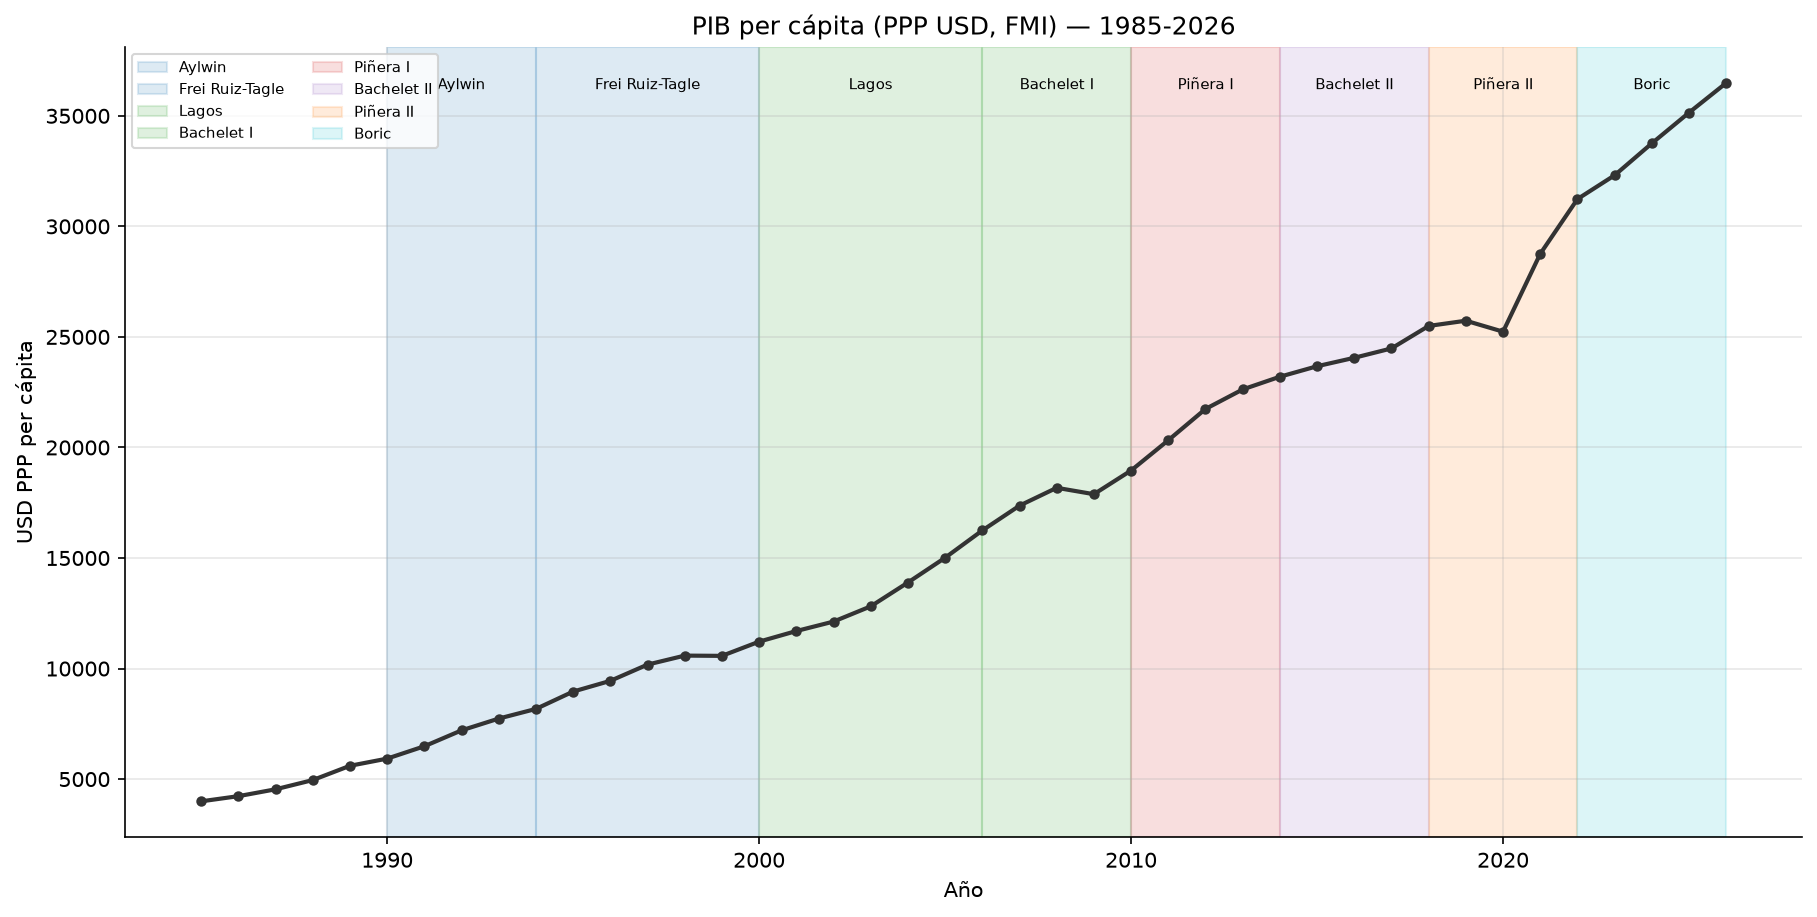

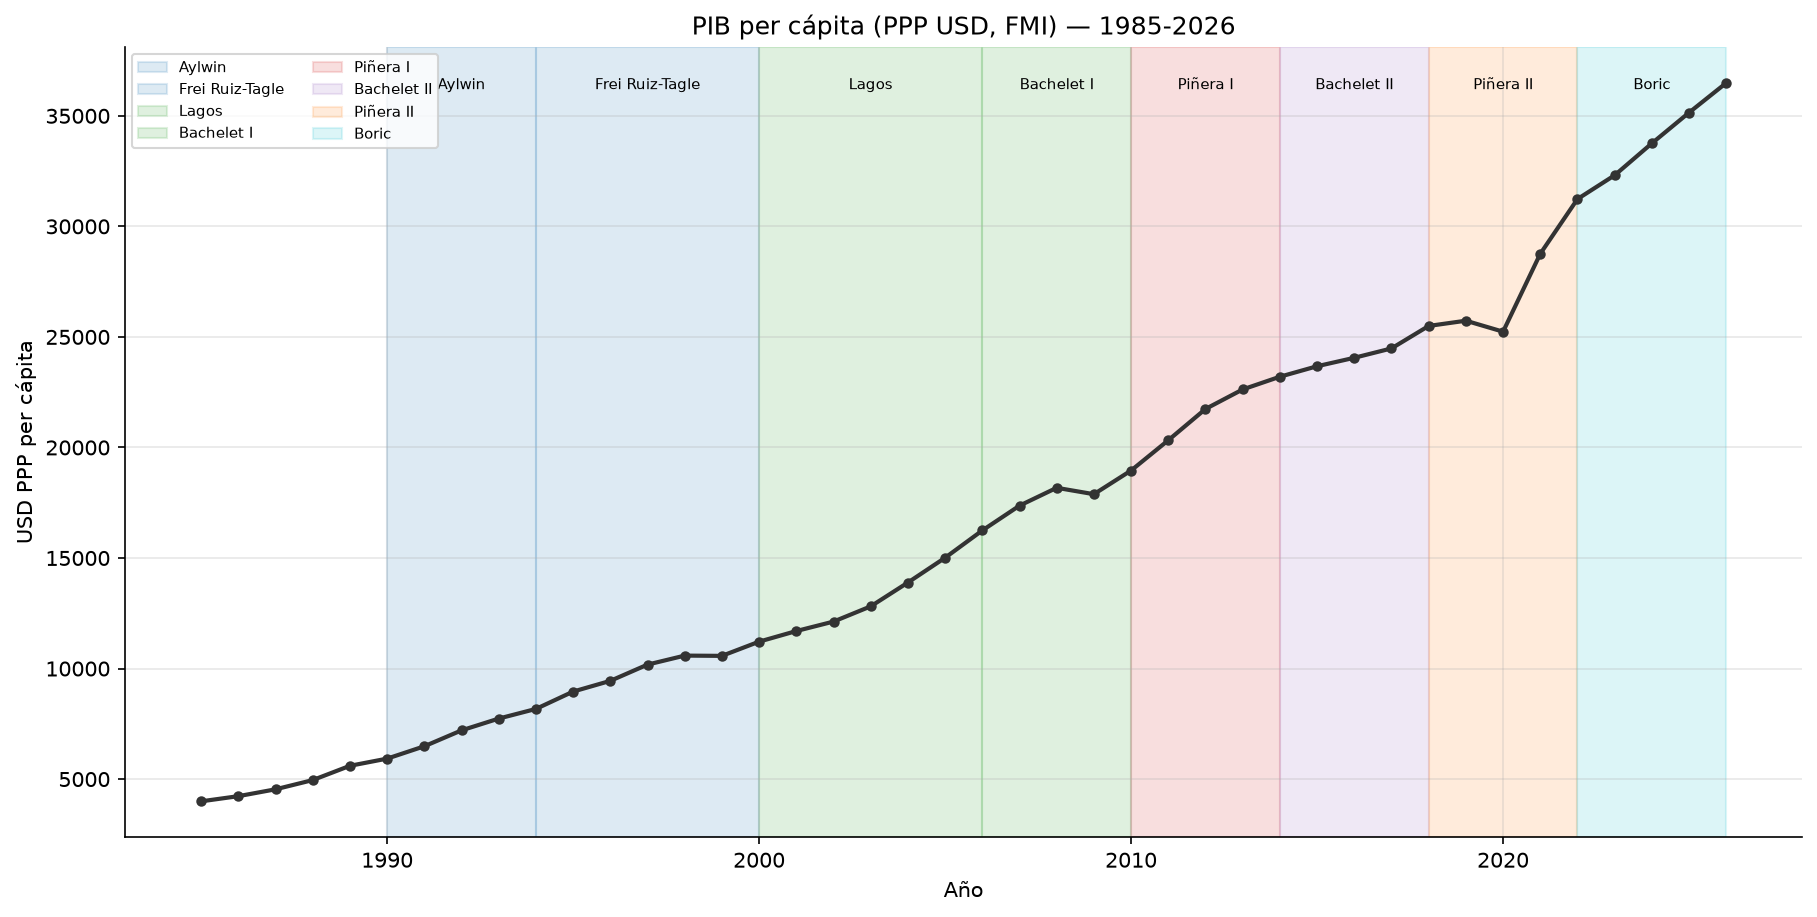

In [4]:
if not HAS_TOKEN:
    print("Sin token: gráfico de PIB per cápita omitido.")
else:
    COALITION_COLORS = {
        "Concertación (PDC)": "#1f77b4",
        "Concertación (PS)": "#2ca02c",
        "Alianza (RN)": "#d62728",
        "Nueva Mayoría (PS)": "#9467bd",
        "Chile Vamos (RN)": "#ff7f0e",
        "Apruebo Dignidad (FA)": "#17becf",
    }

    pib_pc = [(o.date, o.value) for o in data["PIB_PER_CAPITA"] if o.value is not None]
    pib_pc.sort(key=lambda x: x[0])
    years = [int(d[:4]) for d, _ in pib_pc]
    vals = [v for _, v in pib_pc]

    fig, ax = plt.subplots(figsize=(12, 6), dpi=150, layout="constrained")
    ax.plot(years, vals, color="#333333", linewidth=2, marker="o", markersize=4)

    for i, (name, start, end, coalition) in enumerate(GOVERNMENTS):
        y0 = int(start[:4])
        y1 = int(end[:4])
        color = COALITION_COLORS.get(coalition, "#999999")
        ax.axvspan(y0, y1, alpha=0.15, color=color, label=name if i < len(GOVERNMENTS) else "")
        mid = (y0 + y1) / 2
        ax.text(mid, ax.get_ylim()[1] * 0.95, name, ha="center", fontsize=7, rotation=0)

    ax.set_title("PIB per cápita (PPP USD, FMI) — 1985-2026")
    ax.set_ylabel("USD PPP per cápita")
    ax.set_xlabel("Año")
    ax.grid(True, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper left", fontsize=7, ncol=2)
    display(fig)

## Inflación: promedio anualizado por gobierno

**Inflación anualizada** = promedio de las variaciones mensuales del IPC (IPC_VAR)
en el período × 12. Nota: la alta inflación del primer gobierno (Aylwin) refleja
un **proceso de desinflación heredado** de los años 80, no un resultado de política
de ese período.

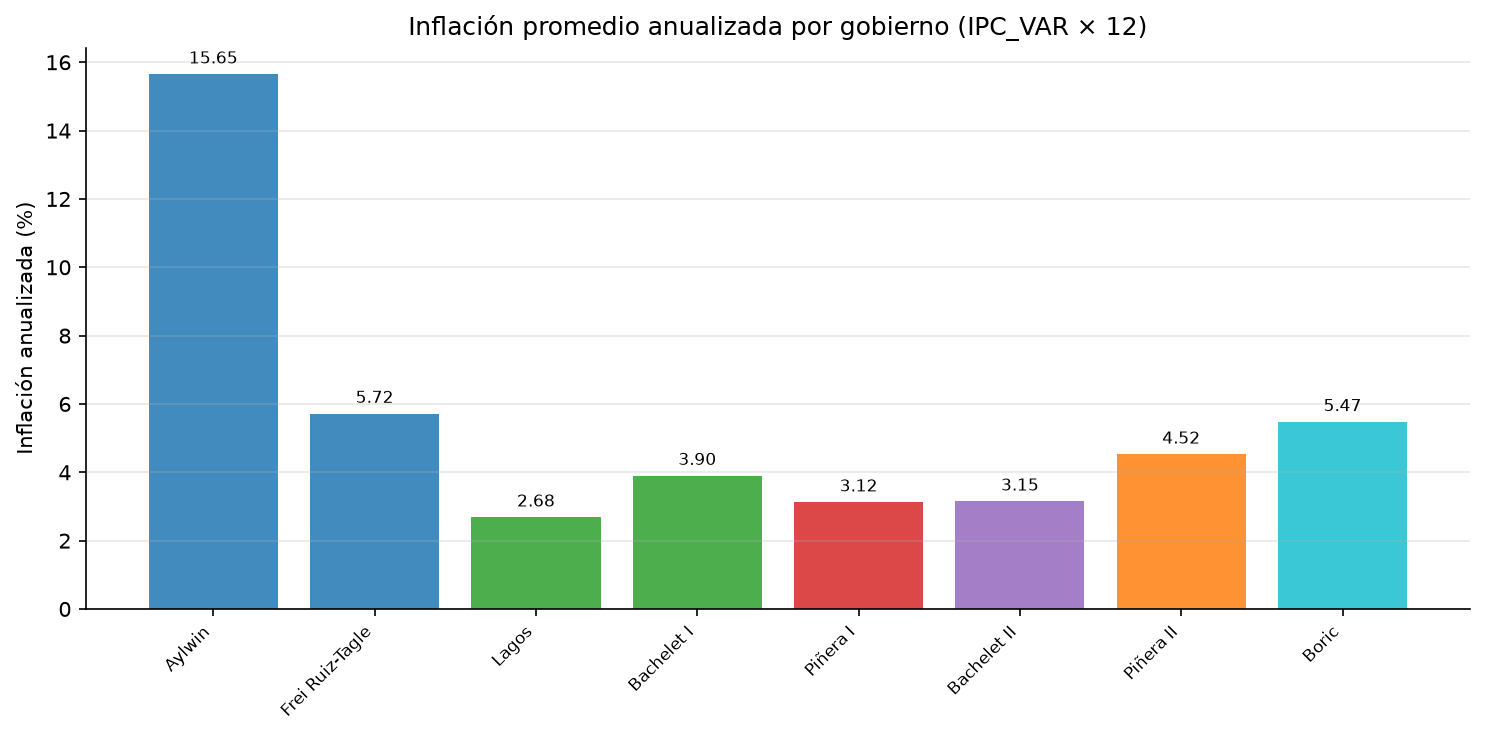

Colores: distinción de coalición, no ranking. '—' = sin datos suficientes (n<12).


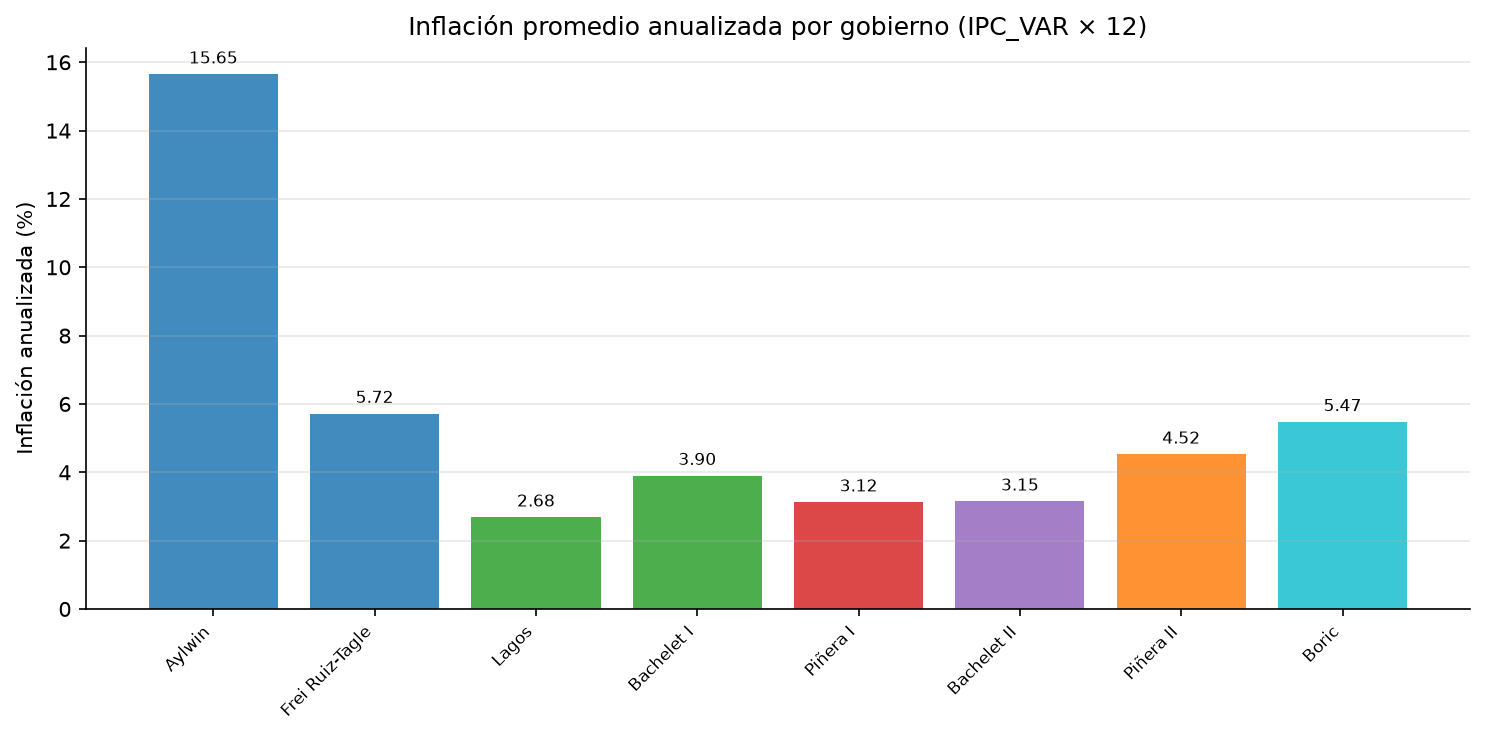

In [5]:
if not HAS_TOKEN:
    print("Sin token: gráfico de inflación omitido.")
else:
    def compute_inflation_annualized(obs_list, start, end):
        vals = [o.value for o in obs_list
                if o.value is not None and start <= o.date < end]
        if len(vals) < 12:
            return None, len(vals)
        return sum(vals) / len(vals) * 12, len(vals)

    inflation_results = []
    for name, start, end, coalition in GOVERNMENTS:
        val, n = compute_inflation_annualized(data["IPC_VAR"], start, end)
        inflation_results.append((name, coalition, val, n))

    names = [r[0] for r in inflation_results]
    values = [r[2] if r[2] is not None else 0 for r in inflation_results]
    colors = [COALITION_COLORS.get(r[1], "#999999") if r[2] is not None else "#cccccc" for r in inflation_results]

    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
    bars = ax.bar(range(len(names)), values, color=colors, alpha=0.85)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Inflación anualizada (%)")
    ax.set_title("Inflación promedio anualizada por gobierno (IPC_VAR × 12)")
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    for i, (bar, r) in enumerate(zip(bars, inflation_results)):
        if r[2] is not None:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f"{r[2]:.2f}", ha="center", va="bottom", fontsize=8)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, 0.5,
                    "—", ha="center", va="bottom", fontsize=8, color="#666666")

    fig.tight_layout()
    display(fig)
    print("Colores: distinción de coalición, no ranking. '—' = sin datos suficientes (n<12).")

## Tipo de cambio: variación del peso por gobierno

Variación porcentual del dólar observado (CLP/USD) durante cada período.
**+ significa depreciación** del peso (se necesitan más pesos por dólar).
Serie diaria; se toma el primer y último valor del período.

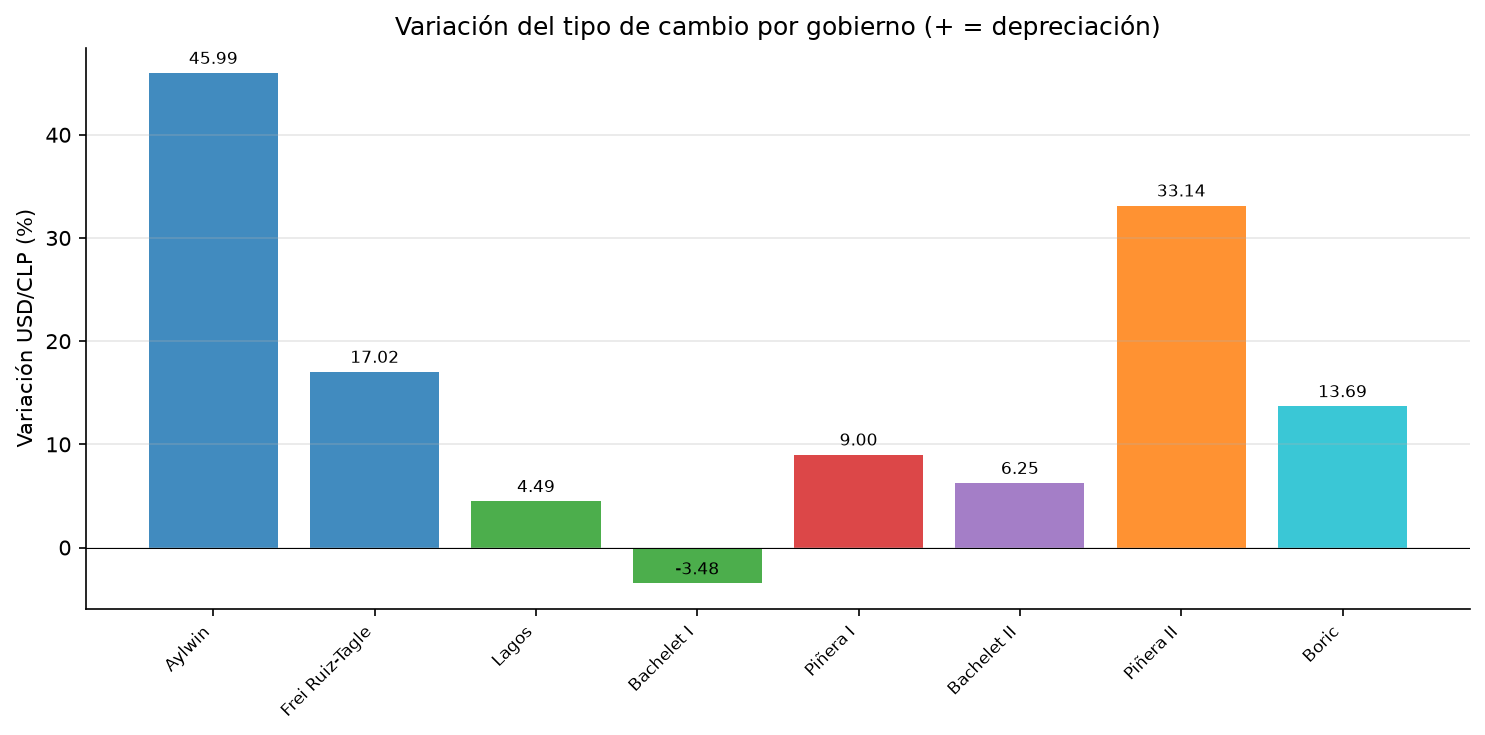

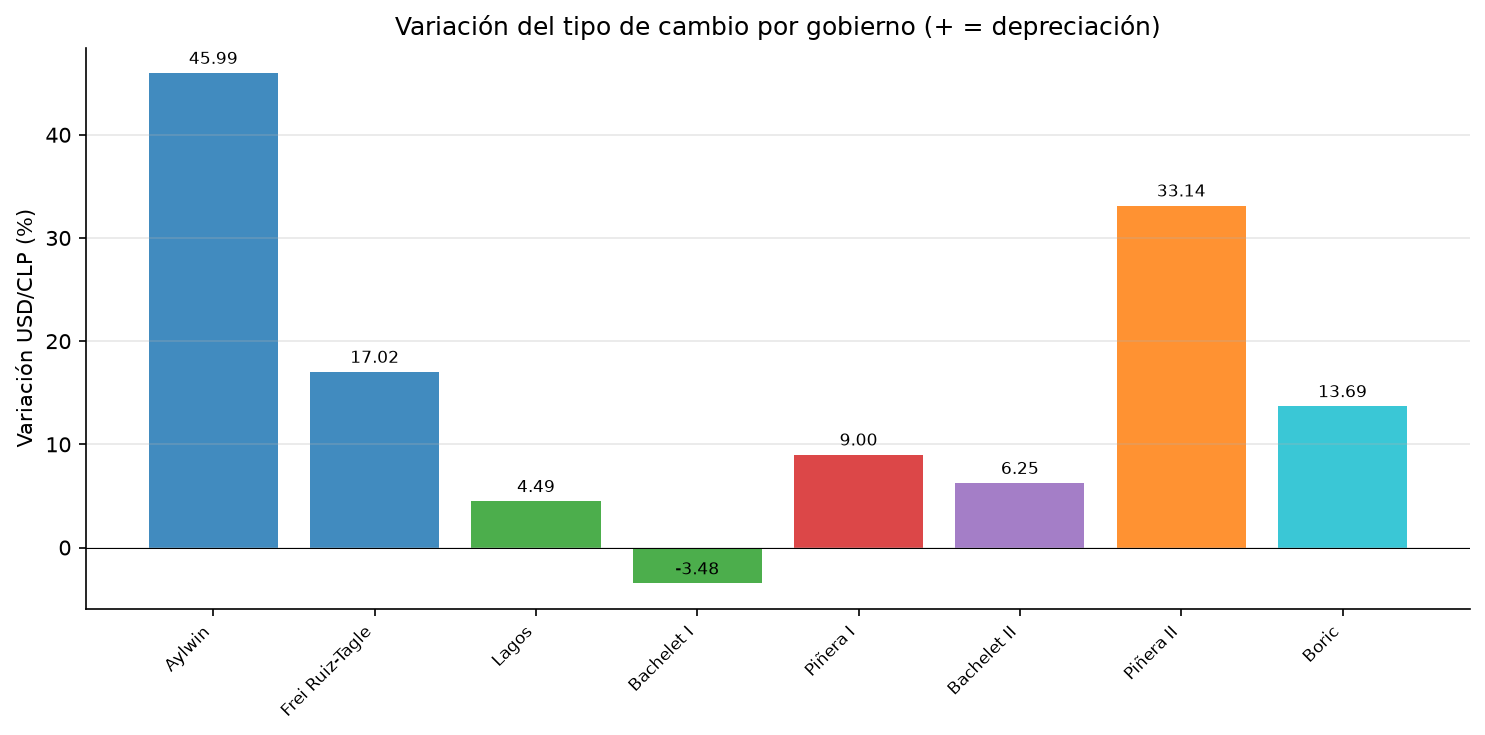

In [6]:
if not HAS_TOKEN:
    print("Sin token: gráfico de tipo de cambio omitido.")
else:
    def compute_pct_change(obs_list, start, end):
        vals = [(o.date, o.value) for o in obs_list
                if o.value is not None and start <= o.date < end]
        if len(vals) < 2:
            return None, len(vals)
        first_val = vals[0][1]
        last_val = vals[-1][1]
        if first_val == 0:
            return None, len(vals)
        return (last_val / first_val - 1) * 100, len(vals)

    usd_results = []
    for name, start, end, coalition in GOVERNMENTS:
        val, n = compute_pct_change(data["USD"], start, end)
        usd_results.append((name, coalition, val, n))

    names = [r[0] for r in usd_results]
    values = [r[2] if r[2] is not None else 0 for r in usd_results]
    colors = [COALITION_COLORS.get(r[1], "#999999") if r[2] is not None else "#cccccc" for r in usd_results]

    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
    bars = ax.bar(range(len(names)), values, color=colors, alpha=0.85)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Variación USD/CLP (%)")
    ax.set_title("Variación del tipo de cambio por gobierno (+ = depreciación)")
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.axhline(y=0, color="black", linewidth=0.5)

    for i, (bar, r) in enumerate(zip(bars, usd_results)):
        if r[2] is not None:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{r[2]:.2f}", ha="center", va="bottom", fontsize=8)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, 0.5,
                    "—", ha="center", va="bottom", fontsize=8, color="#666666")

    fig.tight_layout()
    display(fig)

## Actividad: IMACEC (variación 12 meses promedio) — desde 1996

IMACEC = Indicador Mensual de Actividad Económica (proxy mensual del PIB).
Se calcula la variación interanual (vs 12 meses atrás) para cada observación
y se promedia sobre el período. **Aylwin: sin datos** (IMACEC empieza en 1996).

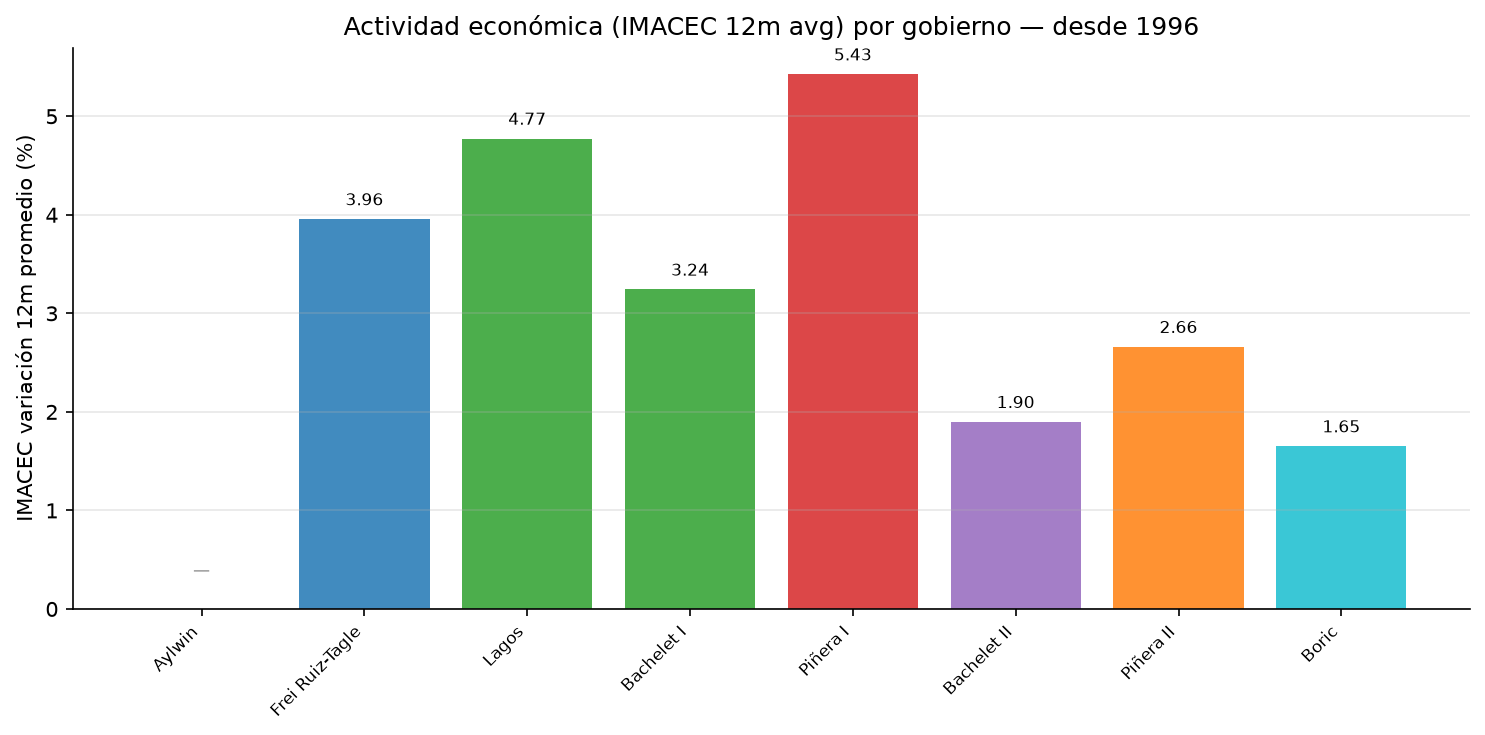

'—' = sin datos suficientes (IMACEC no cubre el período completo).


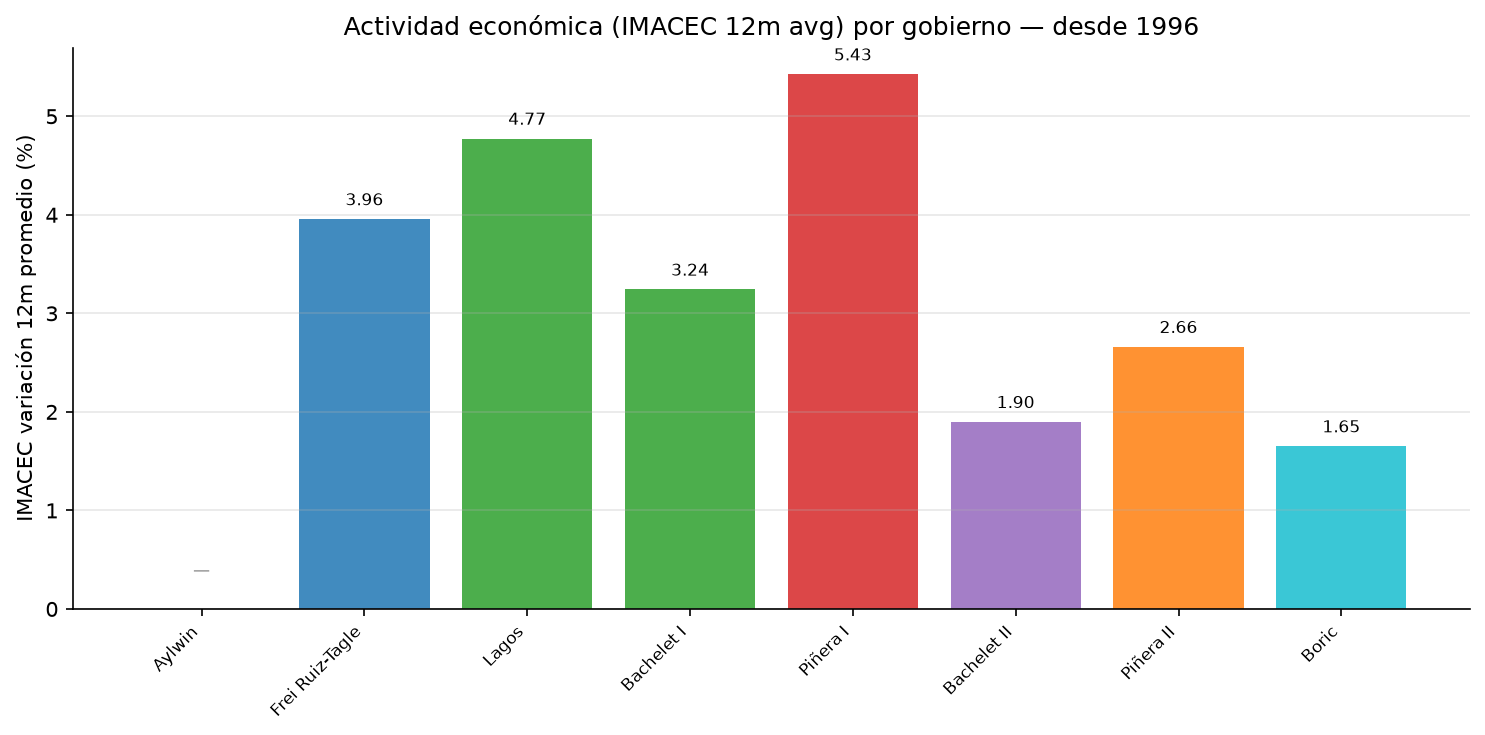

In [7]:
if not HAS_TOKEN:
    print("Sin token: gráfico de IMACEC omitido.")
else:
    def compute_imacec_12m_avg(obs_list, start, end):
        obs_sorted = sorted(
            [(o.date, o.value) for o in obs_list if o.value is not None],
            key=lambda x: x[0]
        )
        date_val = {d: v for d, v in obs_sorted}
        changes = []
        for d, v in obs_sorted:
            if not (start <= d < end):
                continue
            year_ago = f"{int(d[:4])-1}{d[4:]}"
            if year_ago in date_val:
                base = date_val[year_ago]
                if base != 0:
                    changes.append((v - base) / base * 100)
        if len(changes) < 12:
            return None, len(changes)
        return sum(changes) / len(changes), len(changes)

    imacec_results = []
    for name, start, end, coalition in GOVERNMENTS:
        val, n = compute_imacec_12m_avg(data["IMACEC"], start, end)
        imacec_results.append((name, coalition, val, n))

    names = [r[0] for r in imacec_results]
    values = [r[2] if r[2] is not None else 0 for r in imacec_results]
    colors = [COALITION_COLORS.get(r[1], "#999999") if r[2] is not None else "#cccccc" for r in imacec_results]

    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
    bars = ax.bar(range(len(names)), values, color=colors, alpha=0.85)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("IMACEC variación 12m promedio (%)")
    ax.set_title("Actividad económica (IMACEC 12m avg) por gobierno — desde 1996")
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    for i, (bar, r) in enumerate(zip(bars, imacec_results)):
        if r[2] is not None:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f"{r[2]:.2f}", ha="center", va="bottom", fontsize=8)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, 0.3,
                    "—", ha="center", va="bottom", fontsize=8, color="#666666")

    fig.tight_layout()
    display(fig)
    print("'—' = sin datos suficientes (IMACEC no cubre el período completo).")

## Desempleo (tasa promedio) — desde 2010

Tasa de desocupación mensual (INE, vía BCCh). **Solo disponible desde marzo 2010**.
Gobiernos anteriores a Piñera I se muestran como "sin datos suficientes" (gris),
no como cero.

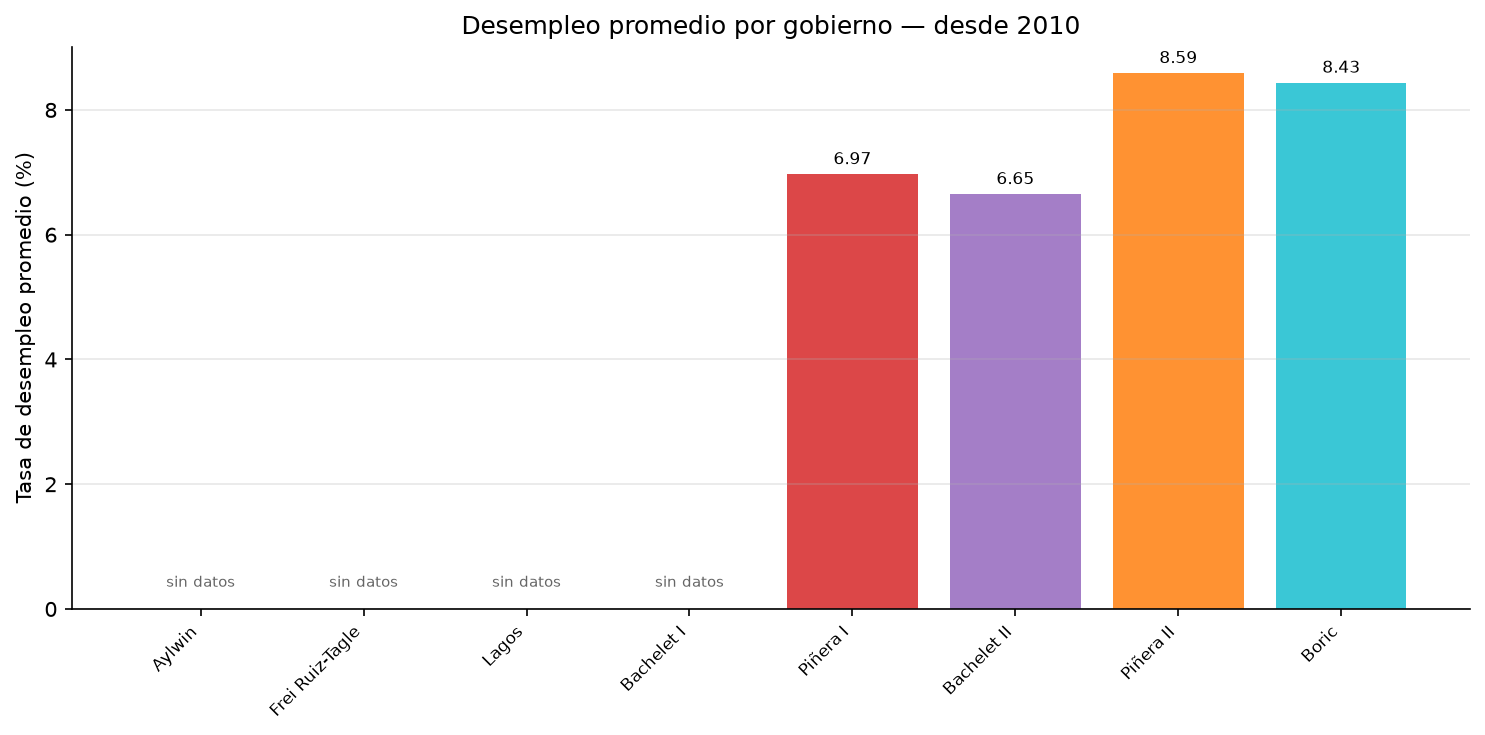

'sin datos' = serie no disponible en ese período (primera obs: 2010-03).


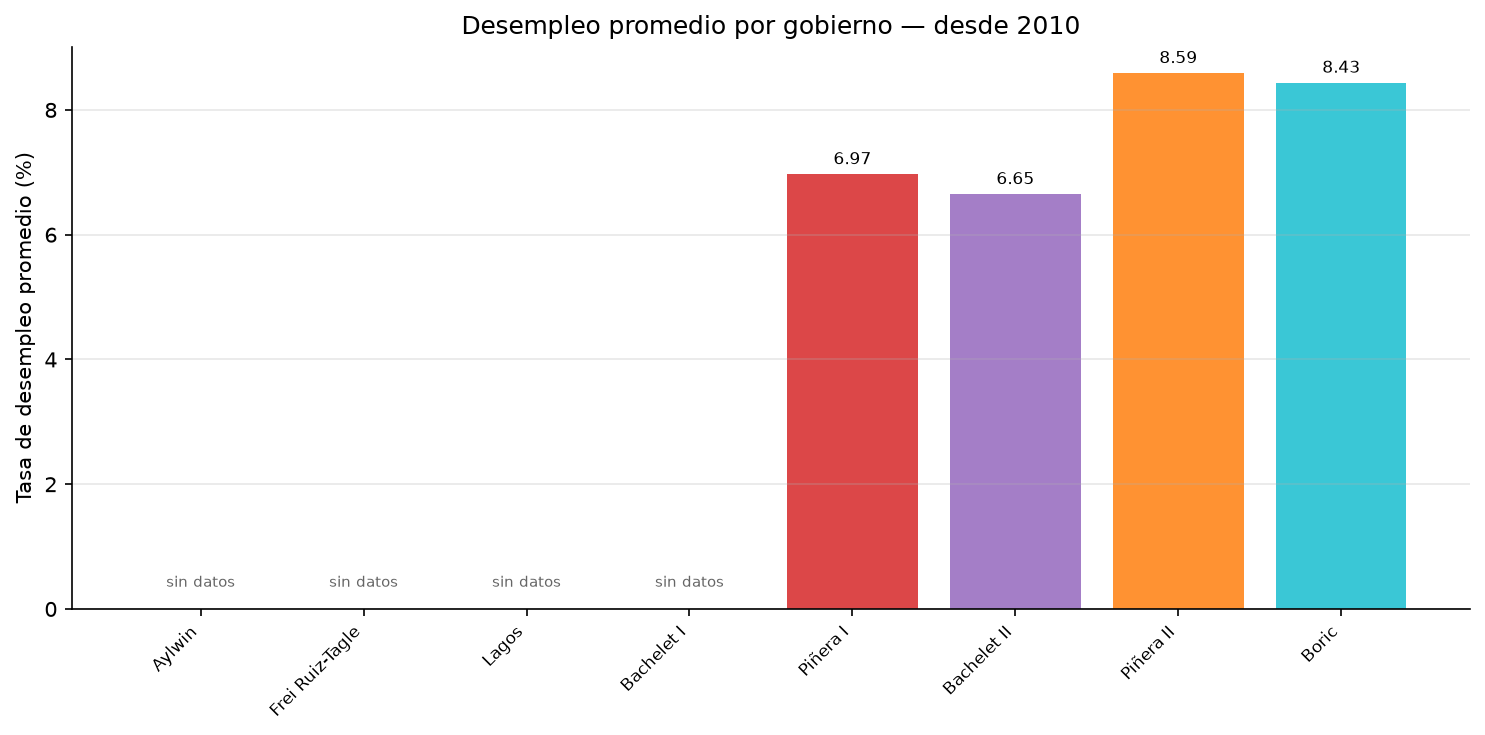

In [8]:
if not HAS_TOKEN:
    print("Sin token: gráfico de desempleo omitido.")
else:
    def compute_mean(obs_list, start, end, min_obs=12):
        vals = [o.value for o in obs_list
                if o.value is not None and start <= o.date < end]
        if len(vals) < min_obs:
            return None, len(vals)
        return sum(vals) / len(vals), len(vals)

    desempleo_results = []
    for name, start, end, coalition in GOVERNMENTS:
        val, n = compute_mean(data["DESEMPLEO"], start, end)
        desempleo_results.append((name, coalition, val, n))

    names = [r[0] for r in desempleo_results]
    values = [r[2] if r[2] is not None else 0 for r in desempleo_results]
    colors = [COALITION_COLORS.get(r[1], "#999999") if r[2] is not None else "#cccccc" for r in desempleo_results]

    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
    bars = ax.bar(range(len(names)), values, color=colors, alpha=0.85)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Tasa de desempleo promedio (%)")
    ax.set_title("Desempleo promedio por gobierno — desde 2010")
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    for i, (bar, r) in enumerate(zip(bars, desempleo_results)):
        if r[2] is not None:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f"{r[2]:.2f}", ha="center", va="bottom", fontsize=8)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, 0.3,
                    "sin datos", ha="center", va="bottom", fontsize=7, color="#666666")

    fig.tight_layout()
    display(fig)
    print("'sin datos' = serie no disponible en ese período (primera obs: 2010-03).")

## Tabla resumen

Todos los métricos por gobierno en una tabla. "—" indica datos insuficientes
para el cálculo (no es cero).

In [9]:
if not HAS_TOKEN:
    print("Sin token: tabla resumen omitida.")
else:
    def compute_pib_pc_pct(obs_list, start, end):
        vals = [(o.date, o.value) for o in obs_list
                if o.value is not None and start <= o.date < end]
        if len(vals) < 2:
            return None
        first_val = vals[0][1]
        last_val = vals[-1][1]
        if first_val == 0:
            return None
        return (last_val / first_val - 1) * 100

    def compute_tpm_mean(obs_list, start, end):
        vals = [o.value for o in obs_list
                if o.value is not None and start <= o.date < end]
        if len(vals) < 12:
            return None
        return sum(vals) / len(vals)

    pib_pc_results = []
    tpm_results = []
    for name, start, end, coalition in GOVERNMENTS:
        pib_pc_results.append(compute_pib_pc_pct(data["PIB_PER_CAPITA"], start, end))
        tpm_results.append(compute_tpm_mean(data["TPM"], start, end))

    header = f"{'Gobierno':<18} {'PIB pc %':>9} {'Infl %':>8} {'USD %':>8} {'IMACEC %':>9} {'Desemp %':>9} {'TPM %':>8}"
    print(header)
    print("-" * len(header))
    for i, (name, _, _, _) in enumerate(GOVERNMENTS):
        pib_pc = f"{pib_pc_results[i]:.2f}" if pib_pc_results[i] is not None else "—"
        infl = f"{inflation_results[i][2]:.2f}" if inflation_results[i][2] is not None else "—"
        usd = f"{usd_results[i][2]:.2f}" if usd_results[i][2] is not None else "—"
        imacec = f"{imacec_results[i][2]:.2f}" if imacec_results[i][2] is not None else "—"
        desemp = f"{desempleo_results[i][2]:.2f}" if desempleo_results[i][2] is not None else "—"
        tpm = f"{tpm_results[i]:.2f}" if tpm_results[i] is not None else "—"
        print(f"{name:<18} {pib_pc:>9} {infl:>8} {usd:>8} {imacec:>9} {desemp:>9} {tpm:>8}")

Gobierno            PIB pc %   Infl %    USD %  IMACEC %  Desemp %    TPM %
---------------------------------------------------------------------------
Aylwin                 26.05    15.65    45.99         —         —        —
Frei Ruiz-Tagle        25.21     5.72    17.02      3.96         —     7.09
Lagos                  38.89     2.68     4.49      4.77         —     3.70
Bachelet I              9.16     3.90    -3.48      3.24         —     4.65
Piñera I               14.13     3.12     9.00      5.43      6.97     4.19
Bachelet II             7.70     3.15     6.25      1.90      6.65     3.17
Piñera II              21.38     4.52    33.14      2.66      8.59     1.87
Boric                  12.92     5.47    13.69      1.65      8.43     7.51


## Explorá vos mismo

Sección interactiva: elegí un métrico del dropdown y se redibuja el gráfico
de barras. Si `ipywidgets` no está instalado, se muestra un mensaje y el
gráfico por defecto con matplotlib.

pip install ipywidgets para la sección interactiva.
Mostrando gráfico por defecto (Inflación):


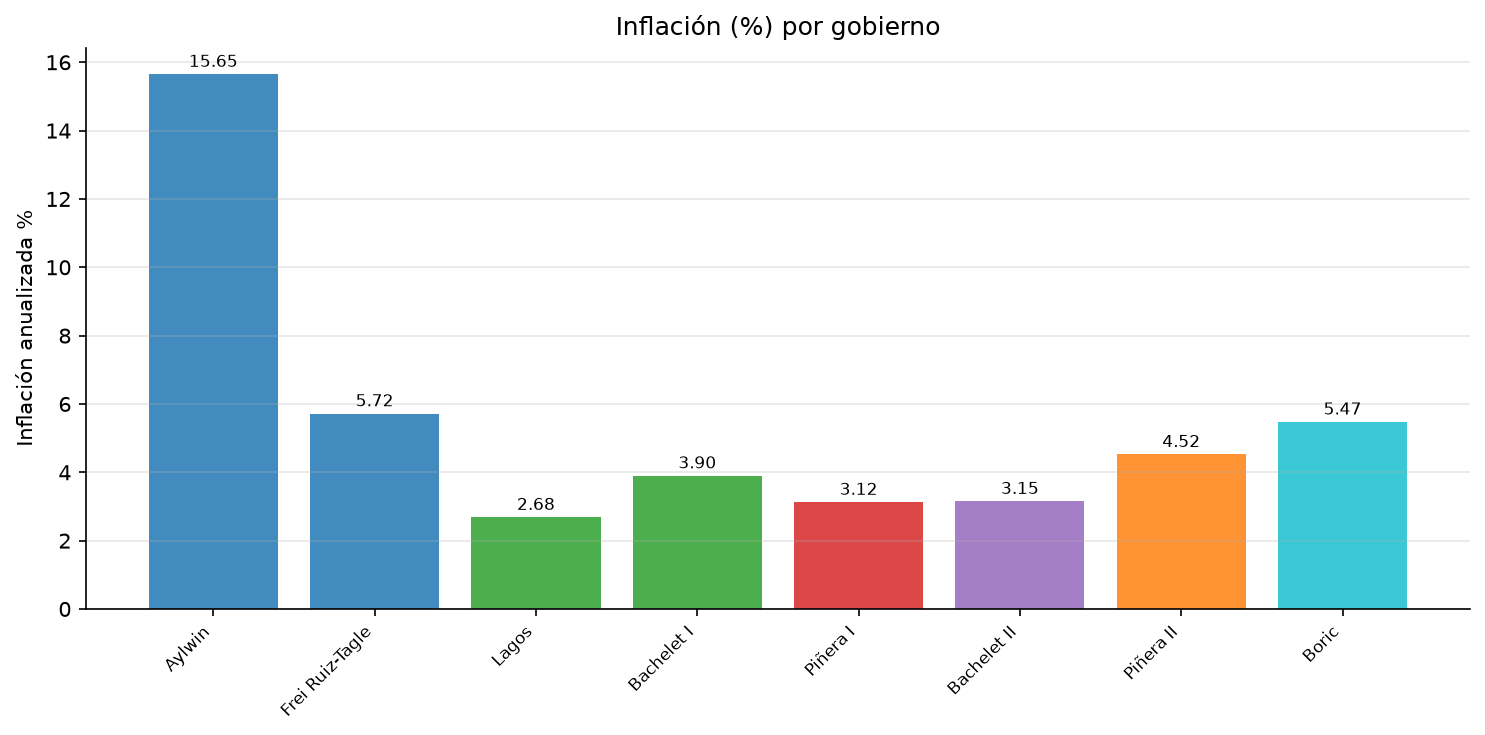

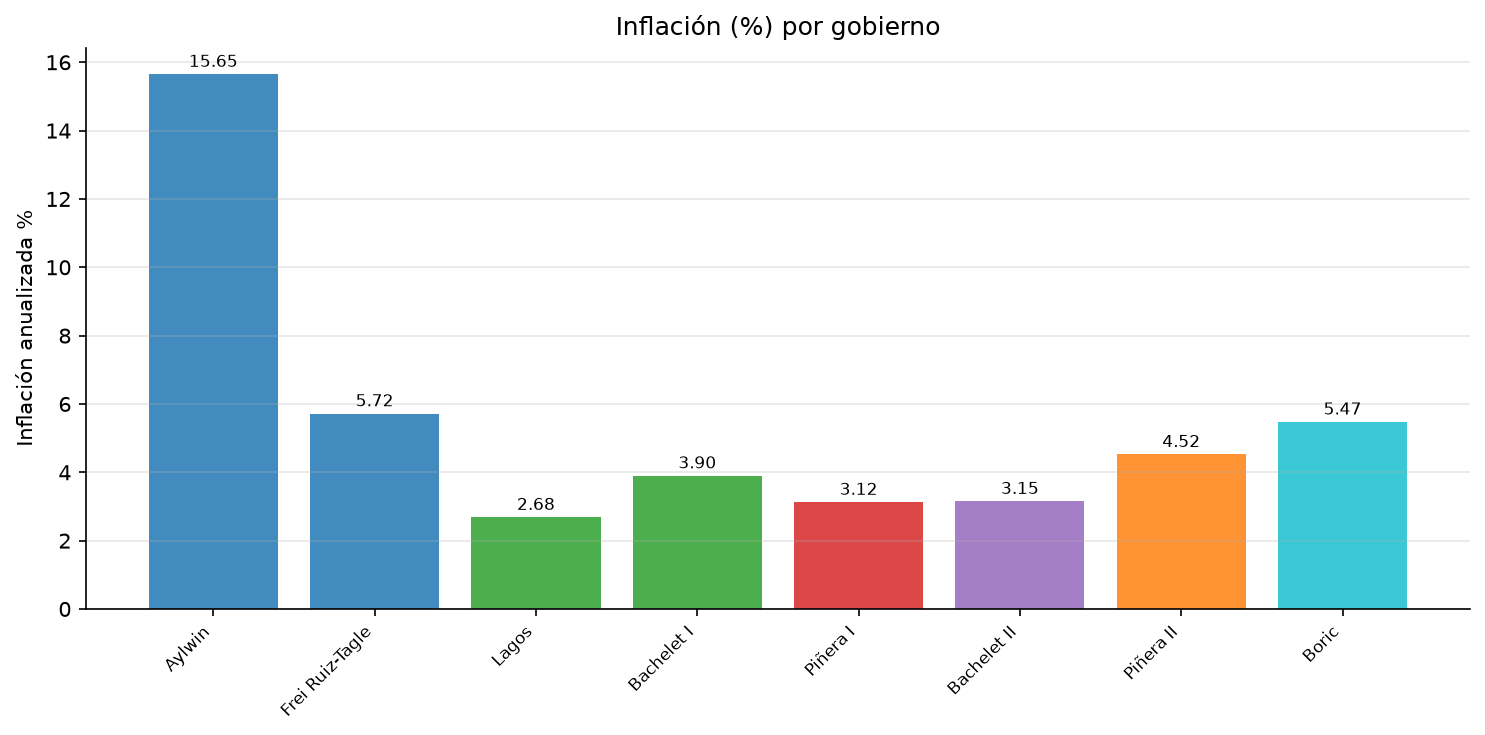

In [10]:
if not HAS_TOKEN:
    print("Sin token: sección interactiva omitida.")
else:
    METRIC_MAP = {
        "PIB per cápita (%)": (pib_pc_results, "PIB per cápita var. %"),
        "Inflación (%)": ([r[2] for r in inflation_results], "Inflación anualizada %"),
        "USD (%)": ([r[2] for r in usd_results], "Variación USD/CLP %"),
        "IMACEC (%)": ([r[2] for r in imacec_results], "IMACEC 12m avg %"),
        "Desempleo (%)": ([r[2] for r in desempleo_results], "Desempleo promedio %"),
        "TPM (%)": (tpm_results, "TPM promedio %"),
    }

    def draw_bar(metric_name):
        values_list, ylabel = METRIC_MAP[metric_name]
        names = [r[0] for r in GOVERNMENTS]
        values = [v if v is not None else 0 for v in values_list]
        colors = [COALITION_COLORS.get(GOVERNMENTS[i][3], "#999999") if values_list[i] is not None else "#cccccc" for i in range(len(names))]

        fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
        bars = ax.bar(range(len(names)), values, color=colors, alpha=0.85)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{metric_name} por gobierno")
        ax.grid(True, axis="y", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
        ax.axhline(y=0, color="black", linewidth=0.5)

        for i, (bar, val) in enumerate(zip(bars, values_list)):
            if val is not None:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=8)
            else:
                ax.text(bar.get_x() + bar.get_width()/2, 0.3,
                        "—", ha="center", va="bottom", fontsize=8, color="#666666")

        fig.tight_layout()
        display(fig)

    try:
        import ipywidgets as widgets
        from ipywidgets import interact

        dropdown = widgets.Dropdown(
            options=list(METRIC_MAP.keys()),
            value="Inflación (%)",
            description="Métrico:",
        )
        out = widgets.interactive_output(draw_bar, {"metric_name": dropdown})
        display(dropdown, out)
    except ImportError:
        print("pip install ipywidgets para la sección interactiva.")
        print("Mostrando gráfico por defecto (Inflación):")
        draw_bar("Inflación (%)")

## Caveats, fuentes y cómo reproducir

**Fuentes:**
- Datos: Banco Central de Chile (BCCh) vía API SIE REST, usando `econchile` v0.2.0.
- PIB per cápita: fuente primaria es el FMI (PPP USD).
- Desempleo: INE (Instituto Nacional de Estadísticas), publicado vía BCCh.

**Caveats:**
- **Empalme / cambio de base**: algunas series (IMACEC, PIB) han cambiado de
  base o metodología. El BCCh publica series empalmadas, pero la comparabilidad
  a 36 años no es perfecta.
- **Series diarias promediadas**: USD y TPM son series diarias; los valores por
  gobierno son promedios sobre el período (no último valor).
- **Cobertura desigual**: no todas las series cubren todos los gobiernos. Ver
  tabla de cobertura arriba.
- **Sin atribución causal**: los números describen períodos, no prueban que un
  gobierno "causó" tal resultado.

**Reproducir:**
```bash
pip install econchile matplotlib ipywidgets
export BCCH_TOKEN=<tu_token>
jupyter notebook examples/chile_gobiernos.ipynb
```

O ejecutar headless:
```bash
jupyter nbconvert --execute examples/chile_gobiernos.ipynb --to notebook --output output.ipynb
```